# PART B: DATA ACQUISITION

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sqlite3
import requests

ModuleNotFoundError: No module named 'matplotlib.backends.registry'

## Load CSV File

In [4]:
df_csv = pd.read_csv("customer_data.csv")
df_csv.head()

FileNotFoundError: [Errno 2] No such file or directory: 'customer_data.csv'

## Load JSON File

In [ ]:
import json

with open("customer_data.json") as f:
    data = json.load(f)

df_json = pd.DataFrame(data["customers"])
df_json.head()

FileNotFoundError: [Errno 2] No such file or directory: 'customer_income.json'

## SQL Data

In [ ]:
conn = sqlite3.connect('customer_profiler.db')
pd.read_sql('SELECT * FROM orders LIMIT 5', conn)

,order_id,customer_id,order_date,amount,category,status,quantity,discount_pct,delivery_days
0,1,411,2022-08-14,9419.51,Clothing,Pending,2,3.8,9
1,2,153,2022-02-16,3535.55,Automotive,Pending,6,0.7,14
2,3,482,2024-05-13,10578.77,Clothing,Shipped,5,2.2,10
3,4,124,2024-07-20,944.06,Clothing,Pending,8,28.1,5
4,5,335,2022-01-11,6378.94,Home & Kitchen,Cancelled,1,4.2,9


## API Data

In [ ]:
url = "https://jsonplaceholder.typicode.com/users"

response = requests.get(url)
api_data = response.json()

df_api = pd.DataFrame(api_data)
df_api.head()

,id,name,username,email,address,phone,website,company
0,1,Leanne Graham,Bret,Sincere@april.biz,"{'street': 'Kulas Light', 'suite': 'Apt. 556',...",1-770-736-8031 x56442,hildegard.org,"{'name': 'Romaguera-Crona', 'catchPhrase': 'Mu..."
1,2,Ervin Howell,Antonette,Shanna@melissa.tv,"{'street': 'Victor Plains', 'suite': 'Suite 87...",010-692-6593 x09125,anastasia.net,"{'name': 'Deckow-Crist', 'catchPhrase': 'Proac..."
2,3,Clementine Bauch,Samantha,Nathan@yesenia.net,"{'street': 'Douglas Extension', 'suite': 'Suit...",1-463-123-4447,ramiro.info,"{'name': 'Romaguera-Jacobson', 'catchPhrase': ..."
3,4,Patricia Lebsack,Karianne,Julianne.OConner@kory.org,"{'street': 'Hoeger Mall', 'suite': 'Apt. 692',...",493-170-9623 x156,kale.biz,"{'name': 'Robel-Corkery', 'catchPhrase': 'Mult..."
4,5,Chelsey Dietrich,Kamren,Lucio_Hettinger@annie.ca,"{'street': 'Skiles Walks', 'suite': 'Suite 351...",(254)954-1289,demarco.info,"{'name': 'Keebler LLC', 'catchPhrase': 'User-c..."


# PART C: DATA UNDERSTANDING & CLEANING

## Initial Exploration

In [ ]:
df = df_json.copy()   # use JSON dataset for analysis

df.head()

,customer_id,name,age,gender,income,city,purchases,avg_order_value,last_purchase_days,total_spent,membership_years,complaints,churn
0,1,Aarav Shah,28,Male,52000.0,Mumbai,12,450.5,15,5406.0,2,0,0
1,2,Priya Mehta,34,Female,78000.0,Delhi,25,820.0,3,20500.0,5,1,0
2,3,Rahul Verma,45,Male,35000.0,Bangalore,5,210.0,90,1050.0,1,3,1
3,4,Sneha Patel,22,Female,29000.0,Ahmedabad,3,180.5,120,541.5,0,1,1
4,5,Karan Joshi,31,Male,61000.0,Pune,18,540.0,10,9720.0,3,0,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   customer_id         50 non-null     int64  
 1   name                50 non-null     object 
 2   age                 50 non-null     int64  
 3   gender              50 non-null     object 
 4   income              49 non-null     float64
 5   city                50 non-null     object 
 6   purchases           50 non-null     int64  
 7   avg_order_value     50 non-null     float64
 8   last_purchase_days  50 non-null     int64  
 9   total_spent         50 non-null     float64
 10  membership_years    50 non-null     int64  
 11  complaints          50 non-null     int64  
 12  churn               50 non-null     int64  
dtypes: float64(3), int64(7), object(3)
memory usage: 5.2+ KB


In [ ]:
df.describe()

,customer_id,age,income,purchases,avg_order_value,last_purchase_days,total_spent,membership_years,complaints,churn
count,50.00000,50.000000,49.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000
mean,25.50000,35.940000,56285.714286,15.780000,539.520000,68.880000,12838.250000,3.320000,1.400000,0.400000
std,14.57738,8.657685,20362.342694,13.010655,342.811425,81.389374,15939.361259,2.606428,1.564922,0.494872
min,1.00000,22.000000,26000.000000,1.000000,100.000000,1.000000,100.000000,0.000000,0.000000,0.000000
25%,13.25000,29.000000,39000.000000,5.000000,222.500000,8.000000,1075.000000,1.000000,0.000000,0.000000
50%,25.50000,34.500000,55000.000000,13.500000,505.000000,26.500000,6830.000000,3.000000,1.000000,0.000000
75%,37.75000,42.750000,72000.000000,23.500000,795.000000,108.750000,18690.000000,5.000000,2.750000,1.000000
max,50.00000,55.000000,95000.000000,50.000000,1350.000000,300.000000,67500.000000,10.000000,5.000000,1.000000


## Missing Values & Duplicates

In [ ]:
df.isnull().sum() 

customer_id           0
name                  0
age                   0
gender                0
income                1
city                  0
purchases             0
avg_order_value       0
last_purchase_days    0
total_spent           0
membership_years      0
complaints            0
churn                 0
dtype: int64

In [ ]:
df.duplicated().sum()

np.int64(0)

## Data Cleaning

In [ ]:
df['income'].fillna(df['income'].mean(), inplace=True)

print(df.isnull().sum())

customer_id           0
name                  0
age                   0
gender                0
income                0
city                  0
purchases             0
avg_order_value       0
last_purchase_days    0
total_spent           0
membership_years      0
complaints            0
churn                 0
dtype: int64


C:\Users\Meet Anghan\AppData\Local\Temp\ipykernel_16912\3792863186.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['income'].fillna(df['income'].mean(), inplace=True)


## Convert Data Types

In [ ]:
conn = sqlite3.connect('customer_profiler.db')  # use sql dataset for analysis
df = pd.read_sql('SELECT * FROM orders', conn)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   order_id       500 non-null    int64  
 1   customer_id    500 non-null    int64  
 2   order_date     500 non-null    object 
 3   amount         500 non-null    float64
 4   category       500 non-null    object 
 5   status         500 non-null    object 
 6   quantity       500 non-null    int64  
 7   discount_pct   500 non-null    float64
 8   delivery_days  500 non-null    int64  
dtypes: float64(2), int64(4), object(3)
memory usage: 35.3+ KB


In [ ]:
df['order_date'] = pd.to_datetime(df['order_date'])

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   order_id       500 non-null    int64         
 1   customer_id    500 non-null    int64         
 2   order_date     500 non-null    datetime64[ns]
 3   amount         500 non-null    float64       
 4   category       500 non-null    object        
 5   status         500 non-null    object        
 6   quantity       500 non-null    int64         
 7   discount_pct   500 non-null    float64       
 8   delivery_days  500 non-null    int64         
dtypes: datetime64[ns](1), float64(2), int64(4), object(2)
memory usage: 35.3+ KB


## Drop Irrelevant Columns

In [ ]:
df = df_json.copy()   # use JSON dataset for analysis
df.drop(columns=['gender'], inplace=True) 


In [ ]:
df.head()

,customer_id,name,age,income,city,purchases,avg_order_value,last_purchase_days,total_spent,membership_years,complaints,churn
0,1,Aarav Shah,28,52000.0,Mumbai,12,450.5,15,5406.0,2,0,0
1,2,Priya Mehta,34,78000.0,Delhi,25,820.0,3,20500.0,5,1,0
2,3,Rahul Verma,45,35000.0,Bangalore,5,210.0,90,1050.0,1,3,1
3,4,Sneha Patel,22,29000.0,Ahmedabad,3,180.5,120,541.5,0,1,1
4,5,Karan Joshi,31,61000.0,Pune,18,540.0,10,9720.0,3,0,0


# PART D: EXPLORATORY DATA ANALYSIS (EDA)

## Univariate Analysis

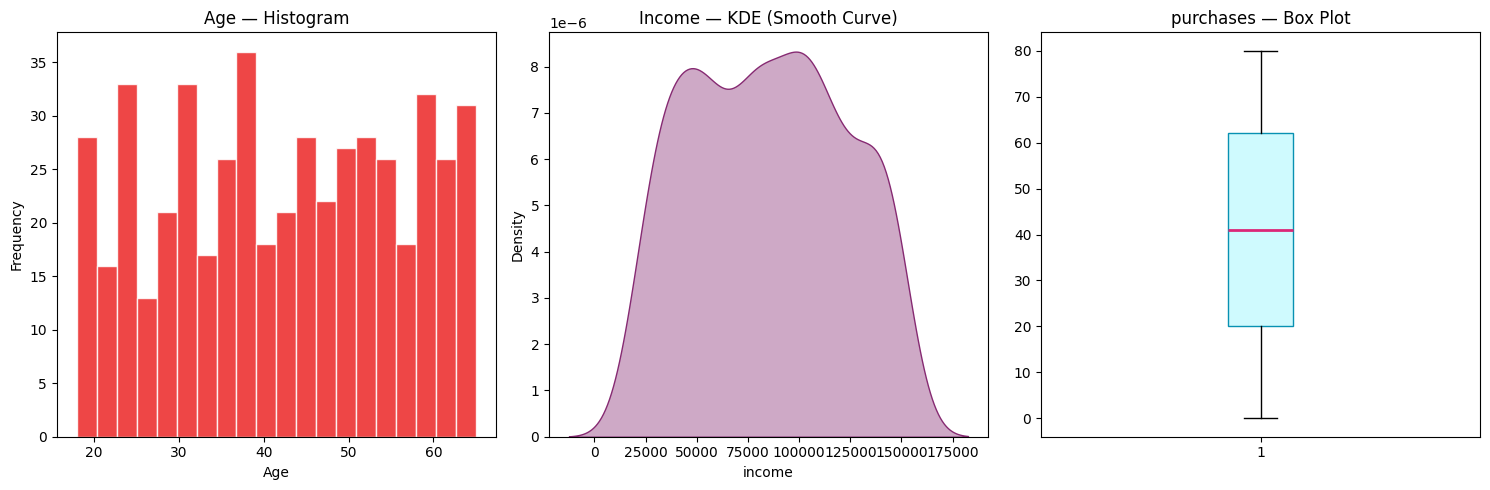

Skewness: -0.06
Kurtosis: -1.18


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('customer_data.csv')

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Histogram
axes[0].hist(df['age'], bins=20, color="#eb2525", edgecolor='white', alpha=0.85)
axes[0].set_title('Age — Histogram')
axes[0].set_xlabel('Age'); axes[0].set_ylabel('Frequency')

# Box Plot
axes[2].boxplot(df['purchases'], patch_artist=True,
                boxprops=dict(facecolor='#cffafe', color='#0891b2'),
                medianprops=dict(color='#db2777', linewidth=2))
axes[2].set_title('purchases — Box Plot')

# KDE Plot
sns.kdeplot(df['income'], ax=axes[1], color="#862a72", fill=True, alpha=0.4)
axes[1].set_title('Income — KDE (Smooth Curve)')

plt.tight_layout()
plt.show()

print(f"Skewness: {df['age'].skew():.2f}")
print(f"Kurtosis: {df['age'].kurtosis():.2f}")


## Bivariate Analysis

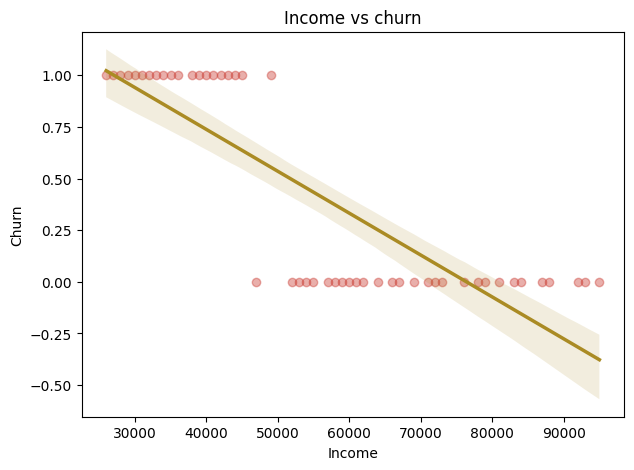

In [ ]:
df = df_json.copy()  

plt.figure(figsize=(7,5))

sns.regplot(
    data=df,
    x='income',
    y='churn',
    color="#C9392F",                
    scatter_kws={'alpha': 0.4},     
    line_kws={'color': "#aa8b24", 'linewidth': 2.5} 
)

plt.xlabel('Income')
plt.ylabel('Churn')
plt.title('Income vs churn')
plt.show()



C:\Users\Meet Anghan\AppData\Local\Temp\ipykernel_16912\3744915858.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


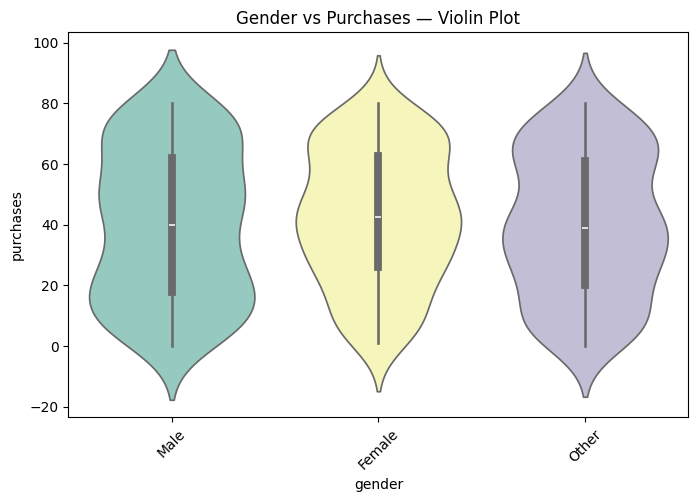

In [ ]:
df = df_csv.copy()  

plt.figure(figsize=(8,5))

sns.violinplot(
    data=df,
    x='gender',
    y='purchases',
    palette='Set3',
    inner="box"  
)

plt.title('Gender vs Purchases — Violin Plot')
plt.xticks(rotation=45)

plt.show()

## Multivariate Analysis

### Correlation Heatmap

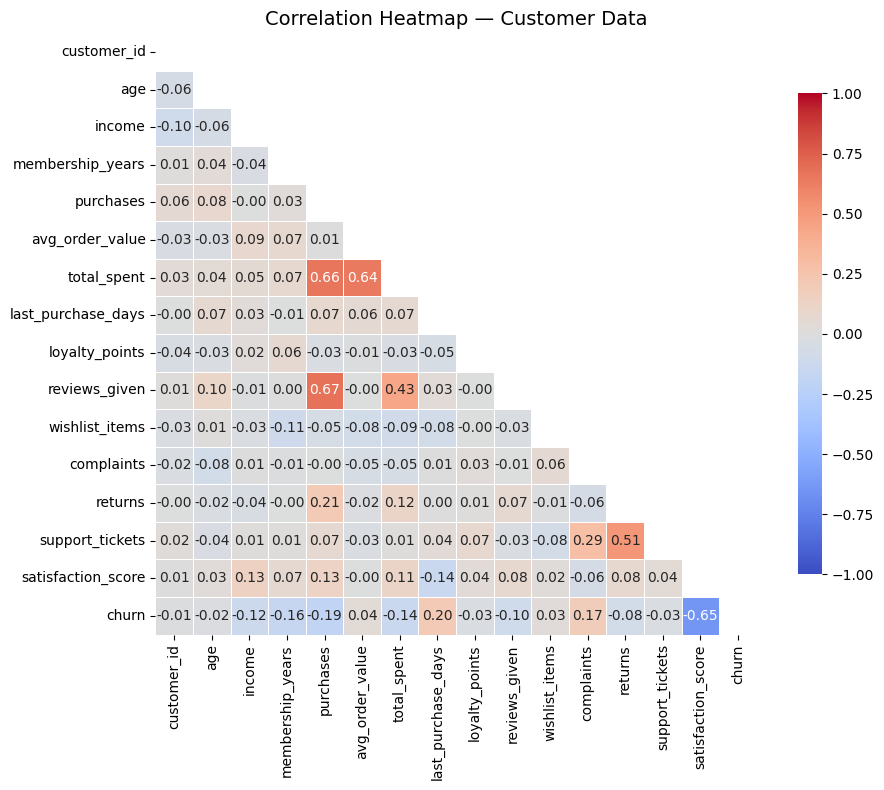

In [ ]:
corr_matrix = df.select_dtypes(include='number').corr()

# Heatmap
plt.figure(figsize=(10, 8))

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    mask=mask,
    vmin=-1, vmax=1,
    linewidths=0.5,
    square=True,
    cbar_kws={'shrink': 0.8}
)

plt.title("Correlation Heatmap — Customer Data", fontsize=14)
plt.tight_layout()
plt.show()

### Pair Plot

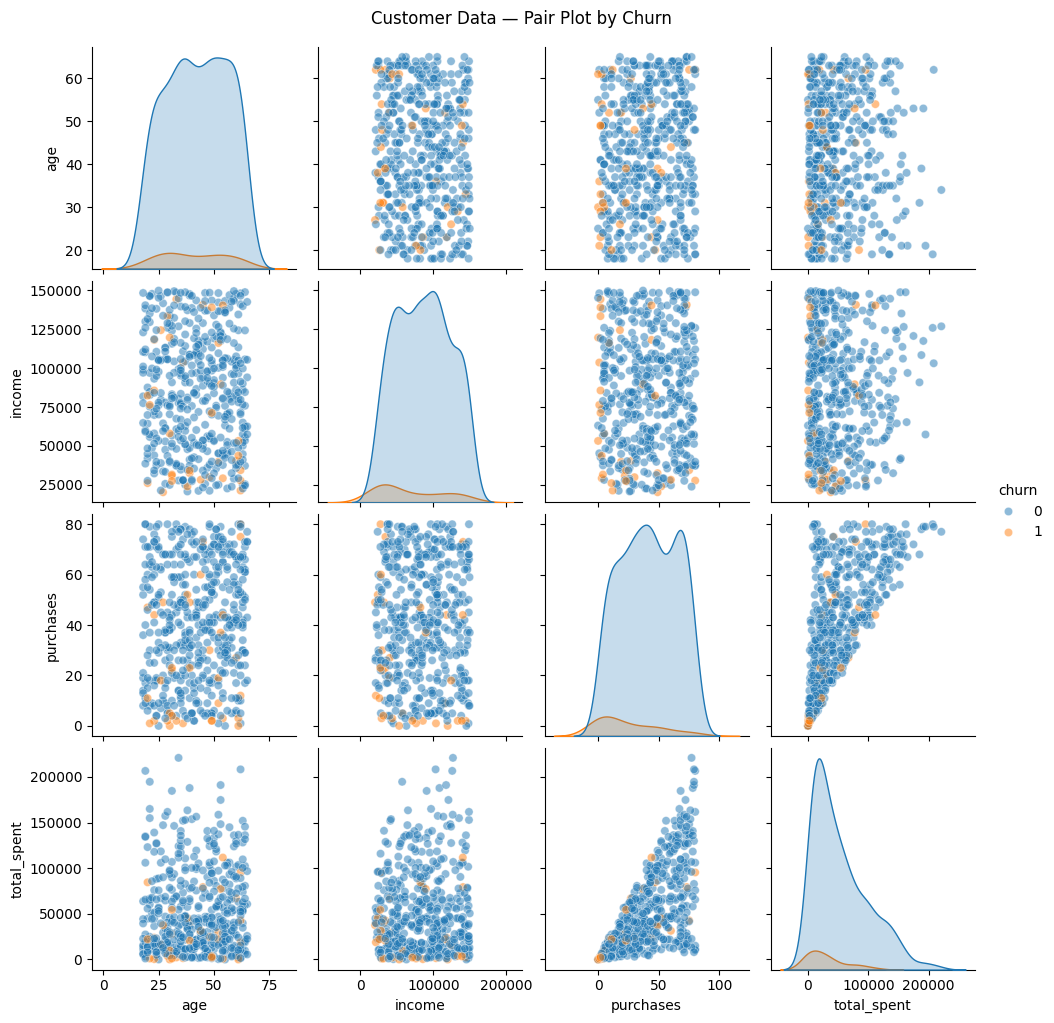

In [ ]:
sns.pairplot(
    df[['age', 'income', 'purchases', 'total_spent', 'churn']],
    hue='churn',
    diag_kind='kde',
    plot_kws={'alpha': 0.5}
)

plt.suptitle("Customer Data — Pair Plot by Churn", y=1.02)
plt.show()

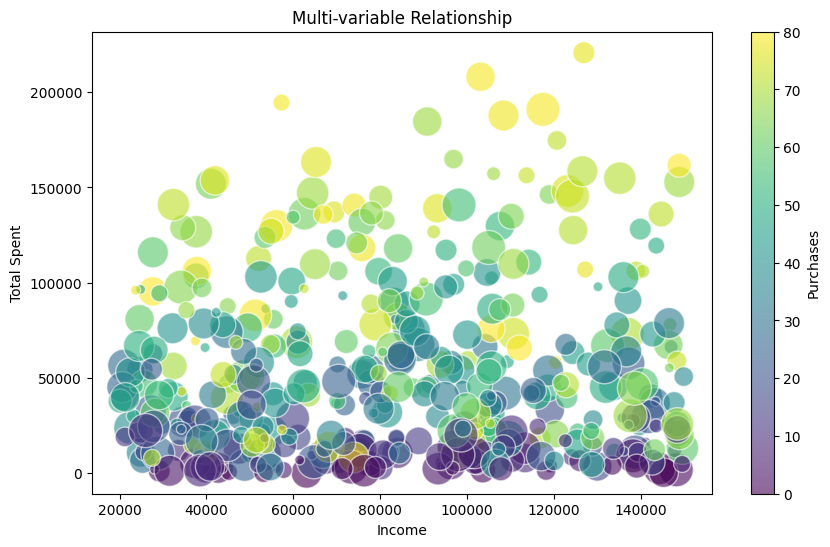

In [ ]:
# Multi-variable Relationship
plt.figure(figsize=(10,6))

scatter = plt.scatter(
    df['income'],
    df['total_spent'],
    c=df['purchases'],      
    s=df['membership_years'] * 50,  
    cmap='viridis',
    alpha=0.6,
    edgecolors='white'
)

plt.colorbar(scatter, label='Purchases')
plt.xlabel("Income")
plt.ylabel("Total Spent")
plt.title("Multi-variable Relationship")

plt.show()

In [ ]:
!pip install ydata_profiling
import pandas as pd
from ydata_profiling import ProfileReport

# Load dataset
df = pd.read_json("customer_data.json")
df = pd.DataFrame(df["customers"])

# Generate full profiling report
profile = ProfileReport(
    df,
    title="Customer Data Profiling Report",
    explorative=True
)

# Save report as HTML
profile.to_file("customer_data_report.html")

print("Report generated successfully!")

# Display inside notebook
profile.to_notebook_iframe()

profile_minimal = ProfileReport(df, minimal=True)
profile_minimal.to_file("quick_report.html")

  Using cached ydata_profiling-4.18.1-py2.py3-none-any.whl.metadata (22 kB)
  Using cached matplotlib-3.10.0-cp313-cp313-win_amd64.whl.metadata (11 kB)
  Using cached visions-0.8.1-py3-none-any.whl.metadata (11 kB)
  Using cached phik-0.12.5-cp313-cp313-win_amd64.whl.metadata (5.6 kB)
  Using cached statsmodels-0.14.6-cp313-cp313-win_amd64.whl.metadata (9.8 kB)
  Using cached ImageHash-4.3.2-py2.py3-none-any.whl.metadata (8.4 kB)
  Using cached wordcloud-1.9.6-cp313-cp313-win_amd64.whl.metadata (3.5 kB)
Using cached ydata_profiling-4.18.1-py2.py3-none-any.whl (400 kB)
Using cached ImageHash-4.3.2-py2.py3-none-any.whl (296 kB)
Using cached matplotlib-3.10.0-cp313-cp313-win_amd64.whl (8.0 MB)
Using cached phik-0.12.5-cp313-cp313-win_amd64.whl (678 kB)
Using cached statsmodels-0.14.6-cp313-cp313-win_amd64.whl (9.5 MB)
Using cached visions-0.8.1-py3-none-any.whl (105 kB)
Using cached wordcloud-1.9.6-cp313-cp313-win_amd64.whl (306 kB)

   ---------------------------------------- 0/7 [matplo

ERROR: Could not install packages due to an OSError: [WinError 5] Access is denied: 'C:\\Users\\Meet Anghan\\AppData\\Local\\Programs\\Python\\Python313\\Lib\\site-packages\\matplotlib\\backends\\_backend_agg.cp313-win_amd64.pyd'
Consider using the `--user` option or check the permissions.


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


ModuleNotFoundError: No module named 'ydata_profiling'